In [1]:
!pip install pennylane pennylane-lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 807.3 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 18.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 43.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 59.1 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import pennylane as qml
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
n_qubits = 8
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    num_layers = weights.shape[0]
    for layer in range(num_layers):
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
        for i in range(n_qubits):
            qml.RZ(weights[layer, i], wires=i)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

weight_shapes = {"weights": (8, n_qubits)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

In [5]:
N_EPOCHS      = 50
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
TRAIN_SUBSET  = 1500
TEST_SUBSET   = 500
NOISE_LEVELS  = [0.0, 0.005, 0.05, 0.10]

In [6]:
class QuantumAlexNet(nn.Module):
    def __init__(self, q_layer, n_qubits, n_classes=10):
        super(QuantumAlexNet, self).__init__()

        alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        self.features = alexnet.features

        for param in self.features.parameters():
            param.requires_grad = False

        self.avgpool = alexnet.avgpool
        self.flatten = nn.Flatten()

        self.dense1 = nn.Linear(9216, 512)
        self.bn1    = nn.BatchNorm1d(512)
        self.act1   = nn.LeakyReLU(0.1)

        self.dense2 = nn.Linear(512, 128)
        self.bn2    = nn.BatchNorm1d(128)
        self.act2   = nn.LeakyReLU(0.1)

        self.linear_reduction = nn.Linear(128, n_qubits)
        self.quantum_layer    = q_layer
        self.classifier       = nn.Linear(n_qubits, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.flatten(x)

        x = self.act1(self.bn1(self.dense1(x)))
        x = self.act2(self.bn2(self.dense2(x)))

        x = self.linear_reduction(x)
        x = torch.sin(x) * (np.pi / 2)

        quantum_outputs = [self.quantum_layer(item) for item in x]
        x = torch.stack(quantum_outputs)
        x = self.classifier(x)
        return x

In [7]:
class AddGaussianNoise:
    def __init__(self, std=0.0):
        self.std = std
    def __call__(self, tensor):
        if self.std == 0.0:
            return tensor
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)


In [8]:
def build_loaders_mnist(noise_std=0.0):
    noise_step = [AddGaussianNoise(std=noise_std)] if noise_std > 0.0 else []

    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),   # grey → RGB
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ] + noise_step)

    train_full = datasets.MNIST(root="./data", train=True,  download=True, transform=tf)
    test_full  = datasets.MNIST(root="./data", train=False, download=True, transform=tf)

    train_loader = DataLoader(Subset(train_full, list(range(TRAIN_SUBSET))),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(Subset(test_full,  list(range(TEST_SUBSET))),
                              batch_size=BATCH_SIZE, shuffle=False)

    print(f"MNIST | noise={noise_std} | train={TRAIN_SUBSET} | test={TEST_SUBSET}")
    return train_loader, test_loader

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total

In [10]:
def run_experiment_mnist(noise_std):
    print(f"\nMNIST | noise={int(noise_std * 100)}%")
    print("\n")

    train_loader, test_loader = build_loaders_mnist(noise_std=noise_std)
    model     = QuantumAlexNet(quantum_layer, n_qubits, n_classes=10).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(f"Epoch [{epoch}/{N_EPOCHS}] "
              f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}% | "
              f"Test Loss: {te_loss:.4f} | Test Acc: {te_acc*100:.2f}%")

    return history

In [11]:
results = {}
for noise in NOISE_LEVELS:
    results[noise] = run_experiment_mnist(noise)
print("\nAll experiments complete.")


MNIST | noise=0%




100%|██████████| 9.91M/9.91M [00:01<00:00, 6.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]


MNIST | noise=0.0 | train=1500 | test=500
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 205MB/s] 


Epoch [1/50] Train Loss: 2.0023 | Train Acc: 30.60% | Test Loss: 1.8621 | Test Acc: 36.40%
Epoch [2/50] Train Loss: 1.7690 | Train Acc: 53.80% | Test Loss: 1.7256 | Test Acc: 67.00%
Epoch [3/50] Train Loss: 1.6378 | Train Acc: 73.67% | Test Loss: 1.6114 | Test Acc: 76.60%
Epoch [4/50] Train Loss: 1.5373 | Train Acc: 78.93% | Test Loss: 1.5063 | Test Acc: 77.80%
Epoch [5/50] Train Loss: 1.4401 | Train Acc: 81.53% | Test Loss: 1.4196 | Test Acc: 81.20%
Epoch [6/50] Train Loss: 1.3479 | Train Acc: 85.60% | Test Loss: 1.3455 | Test Acc: 82.00%
Epoch [7/50] Train Loss: 1.2634 | Train Acc: 89.13% | Test Loss: 1.2681 | Test Acc: 87.20%
Epoch [8/50] Train Loss: 1.1848 | Train Acc: 90.00% | Test Loss: 1.2054 | Test Acc: 85.00%
Epoch [9/50] Train Loss: 1.1179 | Train Acc: 90.20% | Test Loss: 1.1270 | Test Acc: 87.00%
Epoch [10/50] Train Loss: 1.0483 | Train Acc: 90.33% | Test Loss: 1.0715 | Test Acc: 88.00%
Epoch [11/50] Train Loss: 0.9868 | Train Acc: 90.47% | Test Loss: 1.0102 | Test Acc: 87.8

In [12]:
def plot_metrics(results):
    epochs       = list(range(1, N_EPOCHS + 1))
    noise_labels = {0.0: "0% noise", 0.005: "0.5% noise", 0.05: "5% noise", 0.10: "10% noise"}
    colors       = {0.0: "#2196F3",  0.005: "#4CAF50",    0.05: "#FF9800",  0.10: "#F44336"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Quantum AlexNet: MNIST", fontsize=14, fontweight="bold")
    ax_loss, ax_acc = axes

    for noise, history in results.items():
        c = colors[noise]; l = noise_labels[noise]
        ax_loss.plot(epochs, history["train_loss"], color=c, ls="-",  label=f"{l} (train)")
        ax_loss.plot(epochs, history["test_loss"],  color=c, ls="--", label=f"{l} (test)")
        ax_acc.plot(epochs,  [a*100 for a in history["train_acc"]], color=c, ls="-",  label=f"{l} (train)")
        ax_acc.plot(epochs,  [a*100 for a in history["test_acc"]],  color=c, ls="--", label=f"{l} (test)")

    for ax, ylabel, title in zip(
        [ax_loss, ax_acc],
        ["Cross-Entropy Loss", "Accuracy (%)"],
        ["Loss Curves", "Accuracy Curves"]
    ):
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("quantum_alexnet_mnist.png", dpi=150, bbox_inches="tight")
    plt.show()

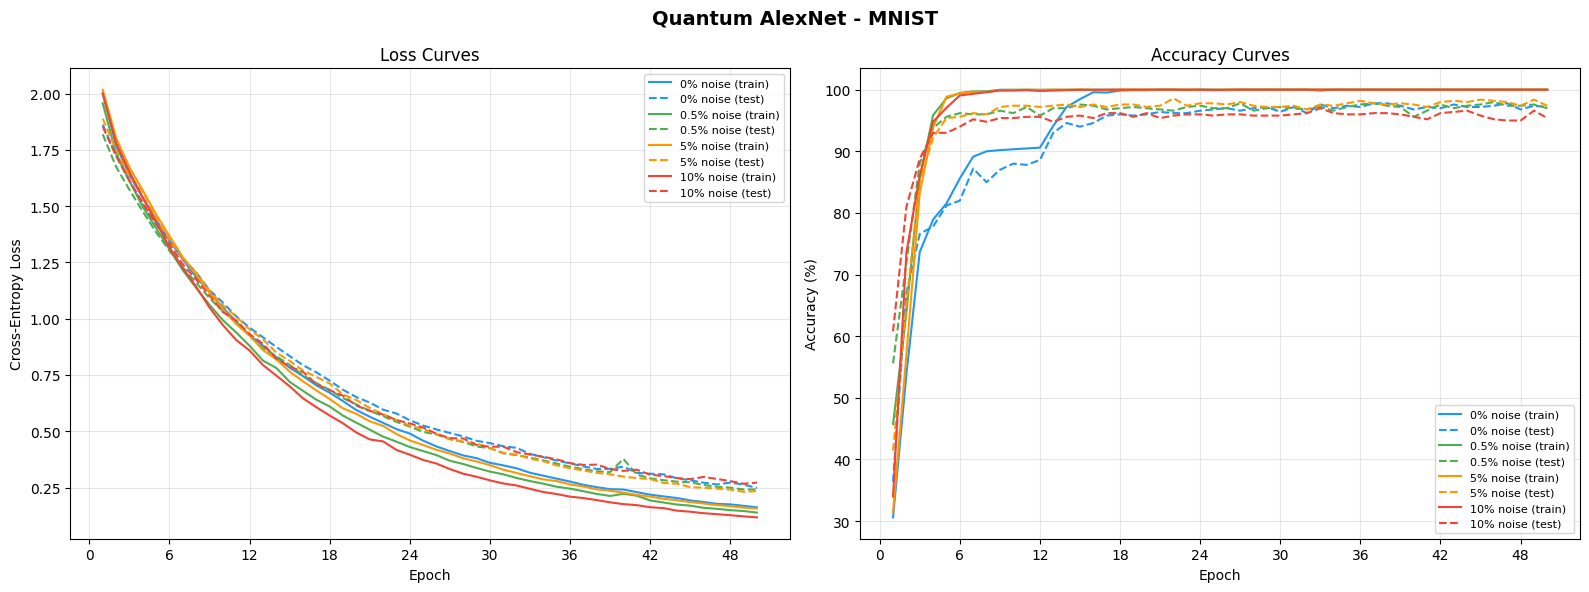


MNIST: Results


   Noise   Final Test Acc  Final Test Loss


      0%            97.20%            0.2480
    0.5%            97.00%            0.2411
      5%            97.40%            0.2341
     10%            95.40%            0.2719




In [15]:
def print_summary(results):
    noise_labels = {0.0: "0%", 0.005: "0.5%", 0.05: "5%", 0.10: "10%"}
    header = f"{'Noise':>8} {'Final Test Acc':>16} {'Final Test Loss':>16}"
    print("\nMNIST: Results")
    print("\n")
    print(header)
    print("\n")
    for noise, history in results.items():
        print(f"{noise_labels[noise]:>8}  {history['test_acc'][-1]*100:>15.2f}%  {history['test_loss'][-1]:>16.4f}")
    print("\n")

plot_metrics(results)
print_summary(results)